In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Feature Engineering Started")

Feature Engineering Started


In [2]:
crop = pd.read_csv("../dataset/Crop_recommendation.csv")
yield_data = pd.read_csv("../dataset/crop_yield_dataset.csv")
sensor = pd.read_csv("../dataset/Smart_Farming_Crop_Yield_2024.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [3]:
# Crop Recommendation Dataset
crop = crop.rename(columns={
    "N": "nitrogen",
    "P": "phosphorus",
    "K": "potassium",
    "ph": "soil_ph",
    "label": "crop"
})

# Crop Yield Dataset
yield_data = yield_data.rename(columns={
    "Crop": "crop",
    "Region": "region",
    "Soil_Type": "soil_type",
    "Soil_pH": "soil_ph",
    "Rainfall_mm": "rainfall",
    "Temperature_C": "temperature",
    "Humidity_pct": "humidity",
    "Fertilizer_Used_kg": "fertilizer_used_kg",
    "Pesticides_Used_kg": "pesticides_used_kg",
    "Planting_Density": "planting_density",
    "Yield_ton_per_ha": "yield_ton_per_ha",
    "Previous_Crop": "previous_crop",
    "Irrigation": "irrigation"
})

# Sensor Dataset
sensor = sensor.rename(columns={
    "crop_type": "crop",
    "soil_moisture_%": "soil_moisture",
    "soil_pH": "soil_ph",
    "temperature_C": "temperature",
    "rainfall_mm": "rainfall",
    "humidity_%": "humidity",
    "NDVI_index": "ndvi",
    "crop_disease_status": "disease_status"
})

print("Column standardization completed!")

Column standardization completed!


In [4]:
crop["soil_fertility_score"] = (
    crop["nitrogen"] +
    crop["phosphorus"] +
    crop["potassium"]
) / 3

crop[["nitrogen", "phosphorus", "potassium", "soil_fertility_score"]].head()

,nitrogen,phosphorus,potassium,soil_fertility_score
0,90,42,43,58.333333
1,85,58,41,61.333333
2,60,55,44,53.000000
3,74,35,40,49.666667
4,78,42,42,54.000000


In [5]:
crop[["nitrogen", "phosphorus", "potassium", "soil_fertility_score"]].head()

,nitrogen,phosphorus,potassium,soil_fertility_score
0,90,42,43,58.333333
1,85,58,41,61.333333
2,60,55,44,53.000000
3,74,35,40,49.666667
4,78,42,42,54.000000


In [6]:
# Normalize weather parameters (0 to 1)

crop["temp_norm"] = (crop["temperature"] - crop["temperature"].min()) / (crop["temperature"].max() - crop["temperature"].min())

crop["humidity_norm"] = (crop["humidity"] - crop["humidity"].min()) / (crop["humidity"].max() - crop["humidity"].min())

crop["rainfall_norm"] = (crop["rainfall"] - crop["rainfall"].min()) / (crop["rainfall"].max() - crop["rainfall"].min())

# Weather Suitability Score

crop["weather_score"] = (
    crop["temp_norm"] +
    crop["humidity_norm"] +
    crop["rainfall_norm"]
) / 3

crop[["temperature","humidity","rainfall","weather_score"]].head()

,temperature,humidity,rainfall,weather_score
0,20.879744,82.002744,202.935536,0.597537
1,21.770462,80.319644,226.655537,0.627917
2,23.004459,82.320763,263.964248,0.692180
3,26.491096,80.158363,242.864034,0.691853
4,20.130175,81.604873,262.717340,0.660411


In [7]:
crop["nitrogen_norm"] = (crop["nitrogen"]-crop["nitrogen"].min())/(crop["nitrogen"].max()-crop["nitrogen"].min())

crop["phosphorus_norm"] = (crop["phosphorus"]-crop["phosphorus"].min())/(crop["phosphorus"].max()-crop["phosphorus"].min())

crop["potassium_norm"] = (crop["potassium"]-crop["potassium"].min())/(crop["potassium"].max()-crop["potassium"].min())

crop["soil_fertility_score"] = (
    crop["nitrogen_norm"] +
    crop["phosphorus_norm"] +
    crop["potassium_norm"]
)/3

crop[["soil_fertility_score"]].head()

,soil_fertility_score
0,0.365714
1,0.388571
2,0.326905
3,0.305952
4,0.335476


In [8]:
crop["crop_health_index"] = (
    crop["soil_fertility_score"]*0.5 +
    crop["weather_score"]*0.5
)

crop[["crop_health_index"]].head()

,crop_health_index
0,0.481626
1,0.508244
2,0.509543
3,0.498903
4,0.497944


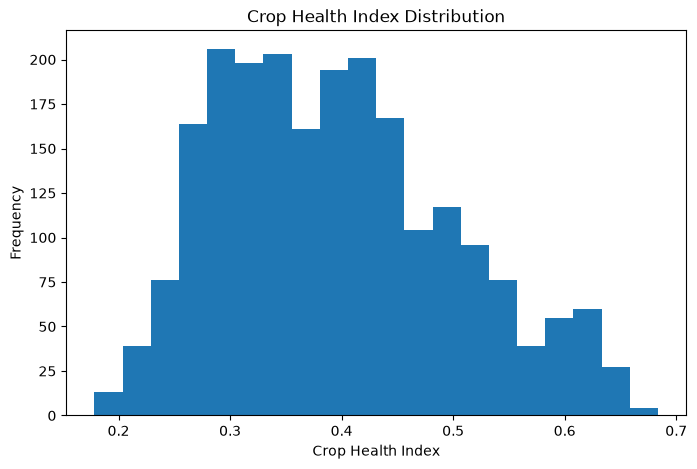

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(crop["crop_health_index"], bins=20)
plt.title("Crop Health Index Distribution")
plt.xlabel("Crop Health Index")
plt.ylabel("Frequency")
plt.show()

In [10]:
crop.to_csv("../dataset/crop_feature_engineered.csv", index=False)

print("Feature Engineered Dataset Saved Successfully!")

Feature Engineered Dataset Saved Successfully!
